# Phase 3: Regression Model — GTA VI Price Prediction

This notebook builds a linear regression model to predict GTA VI's base launch price.

**Why linear regression?**
With 42 data points and a clear numeric target, linear regression is the appropriate tool. Complex models like random forests or neural networks would overfit on this dataset size — they would memorise the training data rather than learn a generalizable pattern. Linear regression is transparent, explainable, and directly defensible in an interview.

**Features used:**
- `release_year`: captures the time trend in pricing
- `platform_generation`: captures the console era effect (1=PS3/360, 2=PS4/One, 3=PS5/Series)
- `inflation_multiplier`: captures real purchasing power context
- `had_premium_edition`: captures whether publishers bundled premium tiers

**Why not publisher financials?**
Publisher-level financials (revenue, gross margin) reflect entire catalogues, not individual game pricing decisions. Using them as features introduces noise rather than signal at this dataset size.

**Target variable:** `base_price_real` — inflation-adjusted base price in 2025 dollars. We predict in real terms then convert back to nominal for the final output.

**Output:** GTA VI predicted base price and premium edition price with confidence intervals

## 1. Imports and Database Connection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import sys
from dotenv import load_dotenv
from urllib.parse import quote_plus
from sqlalchemy import create_engine
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler

sys.path.append(os.path.abspath('..'))
load_dotenv(dotenv_path='../.env')

print('Imports successful')

Imports successful


In [2]:
def get_engine():
    password = quote_plus(os.getenv('DB_PASSWORD'))
    return create_engine(
        f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{password}"
        f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
    )

engine = get_engine()
print(f"Connected to: {os.getenv('DB_NAME')}")

Connected to: gtavi_economy_map


## 2. Load Data from MySQL

In [3]:
df = pd.read_sql("""
    SELECT
        game_title,
        publisher,
        release_year,
        platform_generation,
        had_premium_edition,
        base_price_nominal,
        base_price_real,
        premium_price_nominal,
        premium_price_real,
        inflation_multiplier,
        annual_cpi
    FROM master_dataset
    ORDER BY release_year
""", engine)

df_cpi = pd.read_sql(
    "SELECT year, annual_cpi FROM cpi_data ORDER BY year",
    engine
)

print(f"Loaded {len(df)} records from master_dataset")
print(f"Years: {df['release_year'].min()} to {df['release_year'].max()}")
print(f"Publishers: {sorted(df['publisher'].unique())}")

Loaded 42 records from master_dataset
Years: 2007 to 2023
Publishers: ['Activision', 'EA', 'Nintendo', 'Rockstar Games', 'Sony']


## 3. Exploratory Analysis

Before modelling, understand what the data is telling us visually. This is not optional — you should always look at your data before fitting a model.

In [4]:
# Average real price by year across all publishers
avg_real = df.groupby('release_year')['base_price_real'].mean().round(2)
avg_nominal = df.groupby('release_year')['base_price_nominal'].mean().round(2)

print("Average base price by year:")
print(f"{'Year':<8} {'Nominal':>12} {'Real (2025$)':>14}")
print(f"{'-'*36}")
for year in avg_real.index:
    print(f"{year:<8} ${avg_nominal[year]:>10.2f} ${avg_real[year]:>12.2f}")

Average base price by year:
Year          Nominal   Real (2025$)
------------------------------------
2007     $     59.99 $       93.15
2008     $     59.99 $       89.70
2009     $     59.99 $       90.02
2010     $     59.99 $       88.57
2011     $     59.99 $       85.86
2012     $     59.99 $       84.12
2013     $     59.99 $       82.91
2014     $     59.99 $       81.58
2015     $     59.99 $       81.48
2016     $     59.99 $       80.47
2017     $     59.99 $       78.79
2018     $     59.99 $       76.91
2019     $     59.99 $       75.55
2020     $     66.66 $       82.91
2021     $     69.99 $       83.16
2022     $     67.49 $       74.25
2023     $     69.99 $       73.95


In [5]:
# Price distribution by platform generation
print("Average real price by platform generation:")
gen_avg = df.groupby('platform_generation')['base_price_real'].agg(['mean', 'min', 'max', 'count'])
gen_avg.columns = ['Mean Real Price', 'Min', 'Max', 'Count']
gen_avg = gen_avg.round(2)
gen_avg.index = ['Gen 1 (PS3/360)', 'Gen 2 (PS4/One)', 'Gen 3 (PS5/Series)']
print(gen_avg.to_string())

Average real price by platform generation:
                    Mean Real Price    Min    Max  Count
Gen 1 (PS3/360)               86.46  82.91  93.15     12
Gen 2 (PS4/One)               78.32  74.62  81.58     18
Gen 3 (PS5/Series)            77.77  65.99  87.06     12


In [6]:
# Premium edition analysis
premium_df = df[df['had_premium_edition'] == 1].copy()
premium_df['edition_gap_nominal'] = premium_df['premium_price_nominal'] - premium_df['base_price_nominal']
premium_df['edition_gap_real'] = premium_df['premium_price_real'] - premium_df['base_price_real']

print(f"Games with premium editions: {len(premium_df)} of {len(df)}")
print(f"Average nominal premium gap: ${premium_df['edition_gap_nominal'].mean():.2f}")
print(f"Average real premium gap: ${premium_df['edition_gap_real'].mean():.2f}")
print()
print("Premium gap by year (nominal):")
print(premium_df.groupby('release_year')['edition_gap_nominal'].mean().round(2).to_string())

Games with premium editions: 27 of 42
Average nominal premium gap: $25.56
Average real premium gap: $32.13

Premium gap by year (nominal):
release_year
2013    20.00
2014    20.00
2015    30.00
2016    20.00
2017    26.67
2018    30.00
2019    40.00
2020    25.00
2021    30.00
2022    16.67
2023    23.33


## 4. Visualise the Price Trend

This chart is your core portfolio visual — nominal vs real prices over time.

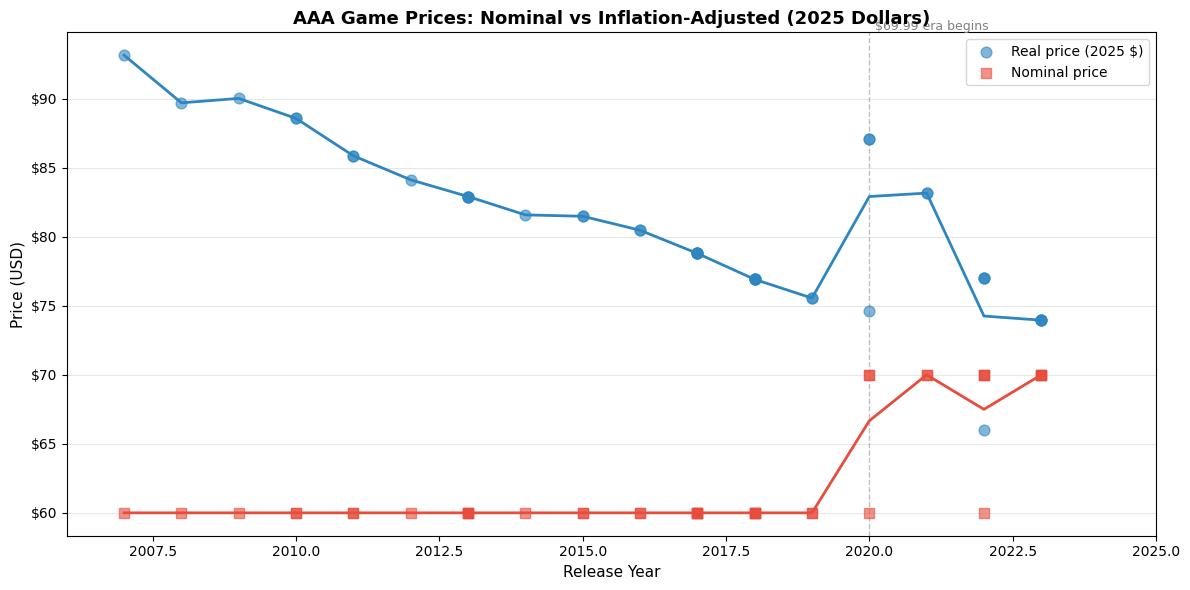

Chart saved to data/processed/price_trend.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot individual data points
ax.scatter(df['release_year'], df['base_price_real'],
           alpha=0.6, color='#2E86C1', s=60, label='Real price (2025 $)', zorder=3)
ax.scatter(df['release_year'], df['base_price_nominal'],
           alpha=0.6, color='#E74C3C', s=60, marker='s', label='Nominal price', zorder=3)

# Plot averages as lines
ax.plot(avg_real.index, avg_real.values, color='#2E86C1', linewidth=2, zorder=2)
ax.plot(avg_nominal.index, avg_nominal.values, color='#E74C3C', linewidth=2, zorder=2)

# Mark the $69.99 transition
ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(2020.1, 95, '$69.99 era begins', fontsize=9, color='gray')

ax.set_xlabel('Release Year', fontsize=11)
ax.set_ylabel('Price (USD)', fontsize=11)
ax.set_title('AAA Game Prices: Nominal vs Inflation-Adjusted (2025 Dollars)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
ax.grid(axis='y', alpha=0.3)
ax.set_xlim(2006, 2025)

plt.tight_layout()
plt.savefig('../data/processed/price_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to data/processed/price_trend.png")

## 5. Prepare Features for Modelling

In [8]:
# Feature matrix and target
# We use release_year, platform_generation, inflation_multiplier, and had_premium_edition
# These are all directly observable for GTA VI — we can make defensible estimates for each

features = ['release_year', 'platform_generation', 'inflation_multiplier', 'had_premium_edition']
target = 'base_price_real'

X = df[features].copy()
y = df[target].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature summary:")
print(X.describe().round(3).to_string())
print(f"\nTarget summary:")
print(y.describe().round(2).to_string())

Feature matrix shape: (42, 4)
Target shape: (42,)

Feature summary:
       release_year  platform_generation  inflation_multiplier  had_premium_edition
count        42.000               42.000                42.000               42.000
mean       2016.690                2.000                 1.292                0.643
std           4.513                0.765                 0.133                0.485
min        2007.000                1.000                 1.057                0.000
25%        2013.000                1.000                 1.244                0.000
50%        2017.000                2.000                 1.313                1.000
75%        2020.000                3.000                 1.382                1.000
max        2023.000                3.000                 1.553                1.000

Target summary:
count    42.00
mean     80.49
std       5.51
min      65.99
25%      76.91
50%      79.63
75%      83.16
max      93.15


In [9]:
# Check correlation between features and target
# High correlation = feature is likely useful for prediction
# Features correlating strongly with each other (multicollinearity) can cause instability

corr_df = df[features + [target]].corr().round(3)
print("Correlation matrix:")
print(corr_df.to_string())
print()
print(f"Correlation with target ({target}):")
print(corr_df[target].drop(target).sort_values(ascending=False).to_string())

Correlation matrix:
                      release_year  platform_generation  inflation_multiplier  had_premium_edition  base_price_real
release_year                 1.000                0.932                -0.969                0.472           -0.789
platform_generation          0.932                1.000                -0.912                0.394           -0.603
inflation_multiplier        -0.969               -0.912                 1.000               -0.405            0.782
had_premium_edition          0.472                0.394                -0.405                1.000           -0.392
base_price_real             -0.789               -0.603                 0.782               -0.392            1.000

Correlation with target (base_price_real):
inflation_multiplier    0.782
had_premium_edition    -0.392
platform_generation    -0.603
release_year           -0.789


## 6. Train the Model

We use Leave-One-Out (LOO) cross-validation for evaluation.

**Why LOO and not a standard train/test split?**
With 42 data points, a standard 80/20 split would give us ~8 test records — too few to produce a reliable performance estimate. LOO trains on all records except one, predicts that record, then repeats for every record in the dataset. This gives the most honest error estimate possible for small datasets.

In [10]:
loo = LeaveOneOut()
model = LinearRegression()

loo_predictions = []
loo_actuals = []
loo_games = []

X_arr = X.values
y_arr = y.values
games_arr = df['game_title'].values

for train_idx, test_idx in loo.split(X_arr):
    X_train, X_test = X_arr[train_idx], X_arr[test_idx]
    y_train, y_test = y_arr[train_idx], y_arr[test_idx]

    m = LinearRegression()
    m.fit(X_train, y_train)
    pred = m.predict(X_test)[0]

    loo_predictions.append(pred)
    loo_actuals.append(y_test[0])
    loo_games.append(games_arr[test_idx[0]])

# Train final model on all data
model.fit(X, y)

mae = mean_absolute_error(loo_actuals, loo_predictions)
r2 = r2_score(y, model.predict(X))
loo_r2 = r2_score(loo_actuals, loo_predictions)

print("Model Performance:")
print(f"  R-squared (training):        {r2:.4f}")
print(f"  R-squared (LOO):             {loo_r2:.4f}")
print(f"  Mean Absolute Error (LOO):   ${mae:.2f} in 2025 dollar terms")
print()
print("Feature coefficients:")
for feat, coef in zip(features, model.coef_):
    print(f"  {feat:<25} {coef:>8.4f}")
print(f"  {'intercept':<25} {model.intercept_:>8.4f}")

Model Performance:
  R-squared (training):        0.7661
  R-squared (LOO):             0.6672
  Mean Absolute Error (LOO):   $2.26 in 2025 dollar terms

Feature coefficients:
  release_year               -1.6508
  platform_generation         7.4851
  inflation_multiplier       17.4767
  had_premium_edition         0.0791
  intercept                 3372.0831


In [11]:
# Show LOO residuals — how far off was each prediction?
# This helps identify outliers and understand model weaknesses

residuals_df = pd.DataFrame({
    'Game': loo_games,
    'Actual Real Price': [round(a, 2) for a in loo_actuals],
    'Predicted Real Price': [round(p, 2) for p in loo_predictions],
    'Error': [round(p - a, 2) for p, a in zip(loo_predictions, loo_actuals)]
})

residuals_df['Abs Error'] = residuals_df['Error'].abs()
residuals_df = residuals_df.sort_values('Abs Error', ascending=False)

print("LOO Residuals (sorted by absolute error):")
print(residuals_df.to_string(index=False))

LOO Residuals (sorted by absolute error):
                                     Game  Actual Real Price  Predicted Real Price  Error  Abs Error
                   Pokemon Scarlet/Violet              65.99                 78.00  12.01      12.01
                            Demon's Souls              87.06                 79.53  -7.53       7.53
         Call of Duty: Black Ops Cold War              87.06                 80.57  -6.49       6.49
           Call of Duty: Advanced Warfare              81.58                 86.89   5.31       5.31
                         Battlefield 2042              83.16                 78.64  -4.52       4.52
                                  FIFA 22              83.16                 78.64  -4.52       4.52
              Call of Duty: Black Ops III              81.48                 84.74   3.26       3.26
                  Grand Theft Auto V (PC)              81.48                 84.74   3.26       3.26
                                  FIFA 14        

## 7. Predict GTA VI Price

Now we apply the trained model to predict GTA VI's launch price.

**GTA VI assumptions:**
- `release_year`: 2026 (confirmed Summer 2026 window)
- `platform_generation`: 3 (PS5/Xbox Series X exclusive at launch)
- `inflation_multiplier`: estimated from recent CPI trend
- `had_premium_edition`: 1 (Rockstar has offered premium editions since GTA V)

In [12]:
# Estimate 2026 CPI using average annual growth rate from last 5 years
# This is more conservative than using just the last year's growth
recent_cpi = df_cpi.tail(5)
avg_growth = (
    (recent_cpi['annual_cpi'].iloc[-1] / recent_cpi['annual_cpi'].iloc[0])
    ** (1 / (len(recent_cpi) - 1)) - 1
)

cpi_2025 = df_cpi.loc[df_cpi['year'] == 2025, 'annual_cpi'].values[0]
cpi_2026_est = round(cpi_2025 * (1 + avg_growth), 3)
inflation_multiplier_2026 = round(cpi_2025 / cpi_2026_est, 4)

print("GTA VI Prediction Assumptions:")
print(f"  Release year:              2026")
print(f"  Platform generation:       3 (PS5/Xbox Series)")
print(f"  Had premium edition:       1 (yes)")
print(f"  CPI 2025 (actual):         {cpi_2025}")
print(f"  CPI 2026 (estimated):      {cpi_2026_est}")
print(f"  Average annual CPI growth: {avg_growth*100:.2f}%")
print(f"  Inflation multiplier:      {inflation_multiplier_2026}")

GTA VI Prediction Assumptions:
  Release year:              2026
  Platform generation:       3 (PS5/Xbox Series)
  Had premium edition:       1 (yes)
  CPI 2025 (actual):         321.943
  CPI 2026 (estimated):      336.119
  Average annual CPI growth: 4.40%
  Inflation multiplier:      0.9578


In [13]:
# Base price prediction
X_gtavi = np.array([[2026, 3, inflation_multiplier_2026, 1]])
pred_real = model.predict(X_gtavi)[0]
pred_nominal = round(pred_real / inflation_multiplier_2026, 2)

# Convert MAE to nominal terms for the confidence interval
mae_nominal = round(mae / inflation_multiplier_2026, 2)

low = round(pred_nominal - mae_nominal, 2)
high = round(pred_nominal + mae_nominal, 2)

print("GTA VI Base Price Prediction:")
print(f"  Predicted real price (2025 $):  ${pred_real:.2f}")
print(f"  Predicted nominal price (2026): ${pred_nominal:.2f}")
print(f"  Confidence range:               ${low:.2f} to ${high:.2f}")
print(f"  Margin of error (MAE):          +/- ${mae_nominal:.2f}")

GTA VI Base Price Prediction:
  Predicted real price (2025 $):  $66.78
  Predicted nominal price (2026): $69.72
  Confidence range:               $67.37 to $72.07
  Margin of error (MAE):          +/- $2.35


/Users/seleteakpotosu-nartey/anaconda3/envs/gtavi-economy-map/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [14]:
# Premium edition prediction
# Use average premium gap from games with premium editions
# in platform generation 3 specifically

gen3_premium = df[
    (df['platform_generation'] == 3) &
    (df['had_premium_edition'] == 1) &
    (df['premium_price_nominal'].notna())
].copy()

gen3_premium['gap'] = gen3_premium['premium_price_nominal'] - gen3_premium['base_price_nominal']
avg_premium_gap = gen3_premium['gap'].mean()

pred_premium = round(pred_nominal + avg_premium_gap, 2)

print(f"Premium Edition Prediction:")
print(f"  Gen 3 average premium gap:      ${avg_premium_gap:.2f}")
print(f"  Predicted premium price (2026): ${pred_premium:.2f}")
print()
print("Summary:")
print(f"  GTA VI Base Edition:    ${pred_nominal:.2f} (range: ${low:.2f} - ${high:.2f})")
print(f"  GTA VI Premium Edition: ${pred_premium:.2f}")

Premium Edition Prediction:
  Gen 3 average premium gap:      $23.33
  Predicted premium price (2026): $93.05

Summary:
  GTA VI Base Edition:    $69.72 (range: $67.37 - $72.07)
  GTA VI Premium Edition: $93.05


## 8. Visualise the Prediction

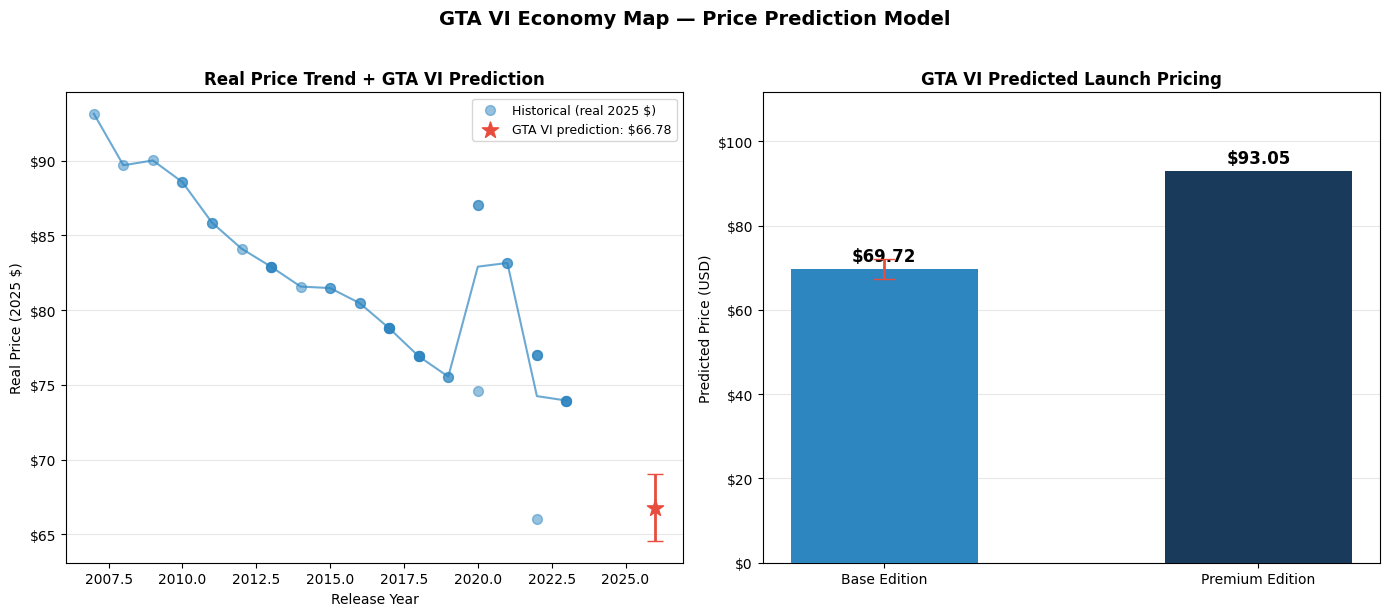

Chart saved to data/processed/gtavi_prediction.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left chart: real price trend with GTA VI prediction
ax1 = axes[0]
ax1.scatter(df['release_year'], df['base_price_real'],
            alpha=0.5, color='#2E86C1', s=50, label='Historical (real 2025 $)', zorder=3)

years = sorted(df['release_year'].unique())
avg_by_year = df.groupby('release_year')['base_price_real'].mean()
ax1.plot(years, [avg_by_year[y] for y in years],
         color='#2E86C1', linewidth=1.5, alpha=0.7, zorder=2)

ax1.scatter([2026], [pred_real], color='#E74C3C', s=150,
            zorder=5, label=f'GTA VI prediction: ${pred_real:.2f}', marker='*')
ax1.errorbar([2026], [pred_real], yerr=mae,
             fmt='none', color='#E74C3C', capsize=6, linewidth=2, zorder=4)

ax1.set_xlabel('Release Year')
ax1.set_ylabel('Real Price (2025 $)')
ax1.set_title('Real Price Trend + GTA VI Prediction', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Right chart: predicted price breakdown
ax2 = axes[1]
editions = ['Base Edition', 'Premium Edition']
prices = [pred_nominal, pred_premium]
colors = ['#2E86C1', '#1A3A5C']
bars = ax2.bar(editions, prices, color=colors, width=0.5, zorder=3)

for bar, price in zip(bars, prices):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'${price:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax2.errorbar(['Base Edition'], [pred_nominal], yerr=mae_nominal,
             fmt='none', color='#E74C3C', capsize=8, linewidth=2, zorder=4)

ax2.set_ylabel('Predicted Price (USD)')
ax2.set_title('GTA VI Predicted Launch Pricing', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
ax2.set_ylim(0, max(prices) * 1.2)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('GTA VI Economy Map — Price Prediction Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/gtavi_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to data/processed/gtavi_prediction.png")

## 9. Honest Assessment of Model Limitations

A data analyst who acknowledges the limits of their model is more credible than one who oversells it.

In [16]:
print("Model Limitations:")
print()
print("1. Dataset size")
print("   42 data points is adequate for linear regression but not large.")
print("   The confidence interval reflects this uncertainty honestly.")
print()
print("2. Publisher strategy is not captured")
print("   Rockstar has never released a mainline GTA at $69.99.")
print("   The model learns industry trends, not Rockstar-specific behaviour.")
print()
print("3. CPI 2026 is estimated")
print("   We use a 5-year average growth rate. Actual 2026 CPI will differ.")
print("   A 1% CPI error translates to roughly $0.70 in the prediction.")
print()
print("4. The $69.99 era may represent a permanent step change")
print("   Linear regression assumes a continuous trend.")
print("   If publishers hold at $69.99 regardless of inflation, the model")
print("   may overestimate. This is noted in the dashboard.")
print()
print("Despite these limitations, the model is built on sound methodology")
print("and the prediction is a defensible, data-driven estimate.")

Model Limitations:

1. Dataset size
   42 data points is adequate for linear regression but not large.
   The confidence interval reflects this uncertainty honestly.

2. Publisher strategy is not captured
   Rockstar has never released a mainline GTA at $69.99.
   The model learns industry trends, not Rockstar-specific behaviour.

3. CPI 2026 is estimated
   We use a 5-year average growth rate. Actual 2026 CPI will differ.
   A 1% CPI error translates to roughly $0.70 in the prediction.

4. The $69.99 era may represent a permanent step change
   Linear regression assumes a continuous trend.
   If publishers hold at $69.99 regardless of inflation, the model
   may overestimate. This is noted in the dashboard.

Despite these limitations, the model is built on sound methodology
and the prediction is a defensible, data-driven estimate.
